In [78]:
import pandas as pd
import numpy as np

In [79]:
df = pd.read_csv("../data/processed/olympic_1896_2024_extended.csv")

df.head()

,Name,Sex,NOC,Year,Sport,Event,Medal
0,A Dijiang,M,CHN,1992,Basketball,Basketball Men's Basketball,NaN
1,A Lamusi,M,CHN,2012,Judo,Judo Men's Extra-Lightweight,NaN
2,Gunnar Nielsen Aaby,M,DEN,1920,Football,Football Men's Football,NaN
3,Edgar Lindenau Aabye,M,DEN,1900,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,Christine Jacoba Aaftink,F,NED,1988,Speed Skating,Speed Skating Women's 500 metres,NaN


In [80]:
summer_years = [
1896, 1900, 1904, 1908, 1912,
1920, 1924, 1928, 1932, 1936,
1948, 1952, 1956, 1960, 1964,
1968, 1972, 1976, 1980, 1984,
1988, 1992, 1996, 2000, 2004,
2008, 2012, 2016, 2020, 2024
]

In [81]:
summer_df = df[df["Year"].isin(summer_years)].copy()

print("Original shape:", df.shape)
print("Summer shape:", summer_df.shape)

Original shape: (275800, 7)
Summer shape: (249518, 7)


In [82]:
summer_df["Gold"]   = (summer_df["Medal"] == "Gold").astype(int)
summer_df["Silver"] = (summer_df["Medal"] == "Silver").astype(int)
summer_df["Bronze"] = (summer_df["Medal"] == "Bronze").astype(int)

In [83]:
summer_df[["Gold","Silver","Bronze"]].sum()

Gold      13768
Silver    13518
Bronze    13831
dtype: int64

In [84]:
# Remove athlete duplication — keep one row per medal event
event_level = (
    summer_df
    .drop_duplicates(subset=["Year", "NOC", "Event", "Medal"])
)

world_summer_medals = (
    event_level
    .groupby(["Year", "NOC"], as_index=False)
    .agg(
        Gold=("Gold", "sum"),
        Silver=("Silver", "sum"),
        Bronze=("Bronze", "sum")
    )
)

world_summer_medals["Total"] = (
    world_summer_medals["Gold"] +
    world_summer_medals["Silver"] +
    world_summer_medals["Bronze"]
)

In [85]:
world_summer_medals.head()

,Year,NOC,Gold,Silver,Bronze,Total
0,1896,AUS,2,0,1,3
1,1896,AUT,2,1,2,5
2,1896,DEN,1,2,3,6
3,1896,FRA,5,4,2,11
4,1896,GBR,3,3,3,9


In [86]:
# Get all unique summer years
all_years = sorted(world_summer_medals["Year"].unique())

# Get all participating NOCs from summer dataset
all_nocs = sorted(
    summer_df["NOC"]
    .dropna()
    .astype(str)
    .unique()
)

# Create full combination grid
full_index = pd.MultiIndex.from_product(
    [all_years, all_nocs],
    names=["Year", "NOC"]
)

full_grid = pd.DataFrame(index=full_index).reset_index()
full_grid.head()

,Year,NOC
0,1896,AFG
1,1896,AHO
2,1896,AIN
3,1896,ALB
4,1896,ALG


In [87]:
world_summer_full = (
    full_grid
    .merge(world_summer_medals, on=["Year", "NOC"], how="left")
)

# Fill missing medal counts with 0
for col in ["Gold", "Silver", "Bronze", "Total"]:
    world_summer_full[col] = world_summer_full[col].fillna(0)

world_summer_full.tail()

,Year,NOC,Gold,Silver,Bronze,Total
6925,2024,YEM,0.0,0.0,0.0,0.0
6926,2024,YMD,0.0,0.0,0.0,0.0
6927,2024,YUG,0.0,0.0,0.0,0.0
6928,2024,ZAM,0.0,0.0,1.0,1.0
6929,2024,ZIM,0.0,0.0,0.0,0.0


In [88]:
summer_hosts = {
    1896: "GRE",
    1900: "FRA",
    1904: "USA",
    1908: "GBR",
    1912: "SWE",
    1920: "BEL",
    1924: "FRA",
    1928: "NED",
    1932: "USA",
    1936: "GER",
    1948: "GBR",
    1952: "FIN",
    1956: "AUS",
    1960: "ITA",
    1964: "JPN",
    1968: "MEX",
    1972: "GER",
    1976: "CAN",
    1980: "URS",
    1984: "USA",
    1988: "KOR",
    1992: "ESP",
    1996: "USA",
    2000: "AUS",
    2004: "GRE",
    2008: "CHN",
    2012: "GBR",
    2016: "BRA",
    2020: "JPN",
    2024: "FRA"
}

In [89]:
# Map host NOC for each year
world_summer_full["host_noc"] = world_summer_full["Year"].map(summer_hosts)

# Create is_host flag
world_summer_full["is_host"] = (
    world_summer_full["NOC"] == world_summer_full["host_noc"]
).astype(int)

world_summer_full[world_summer_full["is_host"] == 1].head()

,Year,NOC,Gold,Silver,Bronze,Total,host_noc,is_host
82,1896,GRE,10.0,17.0,17.0,44.0,GRE,1
301,1900,FRA,28.0,40.0,34.0,102.0,FRA,1
679,1904,USA,76.0,79.0,75.0,230.0,USA,1
768,1908,GBR,56.0,50.0,37.0,143.0,GBR,1
1118,1912,SWE,24.0,24.0,17.0,65.0,SWE,1


In [90]:
def host_baseline(df, year, noc):
    yrs = [year-8, year-4, year+4, year+8]
    return df[
        (df["NOC"] == noc) &
        (df["Year"].isin(yrs))
    ]["Total"].mean()


host_rows = world_summer_full[
    world_summer_full["is_host"] == 1
].copy()

host_rows["baseline_avg"] = host_rows.apply(
    lambda r: host_baseline(world_summer_full, r["Year"], r["NOC"]),
    axis=1
)

host_rows["host_boost"] = (
    host_rows["Total"] - host_rows["baseline_avg"]
)

host_rows[["Year","NOC","Total","baseline_avg","host_boost"]].head()

,Year,NOC,Total,baseline_avg,host_boost
82,1896,GRE,44.0,1.000000,43.000000
301,1900,FRA,102.0,10.666667,91.333333
679,1904,USA,230.0,45.500000,184.500000
768,1908,GBR,143.0,28.333333,114.666667
1118,1912,SWE,65.0,29.666667,35.333333


In [91]:
host_rows["host_boost"].mean()

34.3

In [92]:
# percentage host boost (normalized)
host_rows["host_boost_pct"] = (
    host_rows["host_boost"] / host_rows["baseline_avg"]
) * 100

host_rows[[
    "Year",
    "NOC",
    "Total",
    "baseline_avg",
    "host_boost",
    "host_boost_pct"
]].head()

,Year,NOC,Total,baseline_avg,host_boost,host_boost_pct
82,1896,GRE,44.0,1.000000,43.000000,4300.000000
301,1900,FRA,102.0,10.666667,91.333333,856.250000
679,1904,USA,230.0,45.500000,184.500000,405.494505
768,1908,GBR,143.0,28.333333,114.666667,404.705882
1118,1912,SWE,65.0,29.666667,35.333333,119.101124


In [93]:
host_rows["host_boost_pct"].describe()

count      30.000000
mean      283.678472
std       785.445350
min      -100.000000
25%        41.939855
50%        65.588836
75%       145.745746
max      4300.000000
Name: host_boost_pct, dtype: float64

In [94]:
# ==============================
# STEP 2 — CLEAN HOST BOOST FEATURE (SUMMER)
# ==============================

# 1. Cap extreme outliers (robust)
low_q = host_rows["host_boost_pct"].quantile(0.05)
high_q = host_rows["host_boost_pct"].quantile(0.95)

host_rows["host_boost_pct_capped"] = host_rows["host_boost_pct"].clip(
    lower=low_q,
    upper=high_q
)

# 2. Shift before log to avoid negatives
shift = abs(host_rows["host_boost_pct_capped"].min()) + 1

host_rows["host_boost_log"] = np.log1p(
    host_rows["host_boost_pct_capped"] + shift
)

host_rows[["Year","NOC","host_boost","host_boost_log"]].head()

,Year,NOC,host_boost,host_boost_log
82,1896,GRE,43.000000,6.632764
301,1900,FRA,91.333333,6.632764
679,1904,USA,184.500000,6.028606
768,1908,GBR,114.666667,6.026705
1118,1912,SWE,35.333333,4.857815


In [95]:
# 3. Keep only final host features
host_feature = host_rows[
    ["Year", "NOC", "host_boost", "host_boost_log"]
].copy()

# 4. Merge safely with world_summer_full
world_summer_full = world_summer_full.merge(
    host_feature,
    on=["Year", "NOC"],
    how="left"
)

# 5. Fill non-host rows properly
world_summer_full["host_boost"] = world_summer_full["host_boost"].fillna(0)
world_summer_full["host_boost_log"] = world_summer_full["host_boost_log"].fillna(0)

world_summer_full.head()

,Year,NOC,Gold,Silver,Bronze,Total,host_noc,is_host,host_boost,host_boost_log
0,1896,AFG,0.0,0.0,0.0,0.0,GRE,0,0.0,0.0
1,1896,AHO,0.0,0.0,0.0,0.0,GRE,0,0.0,0.0
2,1896,AIN,0.0,0.0,0.0,0.0,GRE,0,0.0,0.0
3,1896,ALB,0.0,0.0,0.0,0.0,GRE,0,0.0,0.0
4,1896,ALG,0.0,0.0,0.0,0.0,GRE,0,0.0,0.0


In [96]:
# ==============================
# STEP 4 — Long-term & Trend Features (SUMMER)
# ==============================

# Make sure data is sorted properly
world_summer_full = world_summer_full.sort_values(["NOC", "Year"])

# Career average medals till previous Olympics
world_summer_full["career_avg"] = (
    world_summer_full
    .groupby("NOC")["Total"]
    .expanding()
    .mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)

In [97]:
# Recent momentum: last Olympics change
world_summer_full["delta_last"] = (
    world_summer_full
    .groupby("NOC")["Total"]
    .diff()
)

# Fill early NaNs safely
world_summer_full[["career_avg", "delta_last"]] = (
    world_summer_full[["career_avg", "delta_last"]]
    .fillna(0)
)

# Quick sanity check
world_summer_full[
    ["Year", "NOC", "Total", "career_avg", "delta_last"]
].tail(10)

,Year,NOC,Total,career_avg,delta_last
4850,1988,ZIM,0.0,0.050000,0.0
5081,1992,ZIM,0.0,0.047619,0.0
5312,1996,ZIM,0.0,0.045455,0.0
5543,2000,ZIM,0.0,0.043478,0.0
5774,2004,ZIM,3.0,0.041667,3.0
6005,2008,ZIM,4.0,0.160000,1.0
6236,2012,ZIM,0.0,0.307692,-4.0
6467,2016,ZIM,0.0,0.296296,0.0
6698,2020,ZIM,0.0,0.285714,0.0
6929,2024,ZIM,0.0,0.275862,0.0


In [98]:
# ==============================
# PRUNE world_summer_full to final minimal schema
# ==============================

final_cols = [
    "Year",
    "NOC",
    "Total",
    "is_host",
    "host_boost",
    "host_boost_log",
    "career_avg",
    "delta_last"
]

world_summer_master = world_summer_full[final_cols].copy()

world_summer_master.head()

,Year,NOC,Total,is_host,host_boost,host_boost_log,career_avg,delta_last
0,1896,AFG,0.0,0,0.0,0.0,0.0,0.0
231,1900,AFG,0.0,0,0.0,0.0,0.0,0.0
462,1904,AFG,0.0,0,0.0,0.0,0.0,0.0
693,1908,AFG,0.0,0,0.0,0.0,0.0,0.0
924,1912,AFG,0.0,0,0.0,0.0,0.0,0.0


In [99]:
# Safety: fill early NaNs
world_summer_master[["is_host", "career_avg", "delta_last"]] = (
    world_summer_master[["is_host", "career_avg", "delta_last"]]
    .fillna(0)
)

print("Final Summer Master shape:", world_summer_master.shape)
print("Unique Years:", world_summer_master["Year"].nunique())
print("Unique NOCs:", world_summer_master["NOC"].nunique())

Final Summer Master shape: (6930, 8)
Unique Years: 30
Unique NOCs: 231


In [100]:

# load file
df = pd.read_csv("../data/raw/socioeconomics.csv")

# filter GDP per capita
gdp_df = df[df["Series Name"] == "GDP per capita (current US$)"].copy()

# basic sanity checks
print("Shape:", gdp_df.shape)
print("\nUnique Series Names:")
print(gdp_df["Series Name"].unique())

print("\nSample rows:")
gdp_df.head()

Shape: (218, 69)

Unique Series Names:
['GDP per capita (current US$)']

Sample rows:


,Country Name,Country Code,Series Name,Series Code,1960 [YR1960],1961 [YR1961],1962 [YR1962],1963 [YR1963],1964 [YR1964],1965 [YR1965],...,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
2,World,WLD,GDP per capita (current US$),NY.GDP.PCAP.CD,452.253084186565,471.458659222586,495.578743305208,524.598449902349,563.176772281603,601.155818711732,...,10161.9445773234,10204.9287763386,10747.764306505,11309.3830773178,11376.0818134476,10937.6846205191,12390.6686716727,12798.1658465319,13236.7163960917,13631.2043097215
5,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,..,..,..,..,..,..,...,565.569730408751,522.082215583898,525.469770891619,491.337221382603,496.6025042585,510.787063366811,356.496214115892,357.261152798144,413.757894705303,..
8,Albania,ALB,GDP per capita (current US$),NY.GDP.PCAP.CD,..,..,..,..,..,..,...,4199.53912925398,4457.63412207495,5006.36012951959,5897.65452588774,6069.43903131027,6027.91350716348,7242.45513146613,7756.96188744253,9730.86921906893,11377.7757431099
11,Algeria,DZA,GDP per capita (current US$),NY.GDP.PCAP.CD,238.392476666447,209.370672655334,169.60286272133,225.584660210993,238.863801545015,253.622059985778,...,4685.05902729002,4424.98529027556,4554.66753957828,4577.21029180491,4468.45341883656,3743.5419522929,4160.55926736925,4960.30334332888,5370.477235078,5752.99076651465
14,American Samoa,ASM,GDP per capita (current US$),NY.GDP.PCAP.CD,..,..,..,..,..,..,...,12727.4102651386,12843.3342903627,11863.6839452565,12552.0546868861,12886.1359517218,14489.2586563775,15236.1604875571,18017.4589383973,..,..


In [101]:

# identify year columns
year_cols = [c for c in gdp_df.columns if "[YR" in c]

print("Number of year columns:", len(year_cols))
print("First 5 year columns:", year_cols[:5])
print("Last 5 year columns:", year_cols[-5:])

# reshape wide → long
gdp_long = gdp_df.melt(
    id_vars=["Country Name", "Country Code"],
    value_vars=year_cols,
    var_name="year_raw",
    value_name="gdp_pc"
)

gdp_long.head()

Number of year columns: 65
First 5 year columns: ['1960 [YR1960]', '1961 [YR1961]', '1962 [YR1962]', '1963 [YR1963]', '1964 [YR1964]']
Last 5 year columns: ['2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]']


,Country Name,Country Code,year_raw,gdp_pc
0,World,WLD,1960 [YR1960],452.253084186565
1,Afghanistan,AFG,1960 [YR1960],..
2,Albania,ALB,1960 [YR1960],..
3,Algeria,DZA,1960 [YR1960],238.392476666447
4,American Samoa,ASM,1960 [YR1960],..


In [102]:

# extract numeric year from "1960 [YR1960]"
gdp_long["year"] = (
    gdp_long["year_raw"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

# convert GDP per capita to numeric
gdp_long["gdp_pc"] = pd.to_numeric(
    gdp_long["gdp_pc"], errors="coerce"
)

# drop rows with missing GDP values
before_rows = gdp_long.shape[0]
gdp_long = gdp_long.dropna(subset=["gdp_pc"])
after_rows = gdp_long.shape[0]

print(f"Rows before drop: {before_rows}")
print(f"Rows after drop : {after_rows}")

gdp_long.head()

Rows before drop: 14170
Rows after drop : 11634


,Country Name,Country Code,year_raw,gdp_pc,year
0,World,WLD,1960 [YR1960],452.253084,1960
3,Algeria,DZA,1960 [YR1960],238.392477,1960
8,Argentina,ARG,1960 [YR1960],778.251707,1960
11,Australia,AUS,1960 [YR1960],1813.431099,1960
12,Austria,AUT,1960 [YR1960],939.914815,1960


In [103]:
# log-transform GDP per capita
gdp_long["gdp_pc_log"] = np.log(gdp_long["gdp_pc"])

# quick sanity check
print(gdp_long[["gdp_pc", "gdp_pc_log"]].describe())

gdp_long.head()

              gdp_pc    gdp_pc_log
count   11634.000000  11634.000000
mean     9633.366536      7.787791
std     18986.517119      1.765789
min        11.801322      2.468212
25%       617.284575      6.425330
50%      2204.022183      7.698039
75%      9402.213489      9.148700
max    288001.433369     12.570721


,Country Name,Country Code,year_raw,gdp_pc,year,gdp_pc_log
0,World,WLD,1960 [YR1960],452.253084,1960,6.114242
3,Algeria,DZA,1960 [YR1960],238.392477,1960,5.473918
8,Argentina,ARG,1960 [YR1960],778.251707,1960,6.657050
11,Australia,AUS,1960 [YR1960],1813.431099,1960,7.502976
12,Austria,AUT,1960 [YR1960],939.914815,1960,6.845789


In [104]:
# ================================
# FINAL GDP MERGE + FREEZE SCHEMA
# ================================

# 1. Rename GDP columns to align
gdp_long_final = (
    gdp_long
    .rename(columns={
        "Country Code": "NOC",
        "year": "Year"
    })
)

# 2. Enforce dtype
gdp_long_final["Year"] = gdp_long_final["Year"].astype(int)
world_summer_master["Year"] = world_summer_master["Year"].astype(int)

# 3. Sort (required)
gdp_long_final = gdp_long_final.sort_values(["NOC", "Year"])
world_summer_master = world_summer_master.sort_values(["NOC", "Year"])

# 4. Safe asof merge per NOC
world_summer_master = (
    world_summer_master
    .groupby("NOC", group_keys=False)
    .apply(
        lambda x: pd.merge_asof(
            x,
            gdp_long_final[gdp_long_final["NOC"] == x.name],
            on="Year",
            direction="backward"
        )
    )
)

world_summer_master.head()

C:\Users\Kashyap Ladva\AppData\Local\Temp\ipykernel_23208\302708155.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,Year,NOC_x,Total,is_host,host_boost,host_boost_log,career_avg,delta_last,Country Name,NOC_y,year_raw,gdp_pc,gdp_pc_log
0,1896,AFG,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,1900,AFG,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,1904,AFG,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
3,1908,AFG,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,1912,AFG,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [105]:
world_summer_master.columns


Index(['Year', 'NOC_x', 'Total', 'is_host', 'host_boost', 'host_boost_log',
       'career_avg', 'delta_last', 'Country Name', 'NOC_y', 'year_raw',
       'gdp_pc', 'gdp_pc_log'],
      dtype='object')

In [106]:
# Fix NOC column
world_summer_master.rename(columns={"NOC_x": "NOC"}, inplace=True)

# Drop unnecessary columns from GDP merge
cols_to_drop = ["NOC_y", "Country Name", "year_raw"]
cols_to_drop = [c for c in cols_to_drop if c in world_summer_master.columns]

world_summer_master.drop(columns=cols_to_drop, inplace=True)

world_summer_master.columns

Index(['Year', 'NOC', 'Total', 'is_host', 'host_boost', 'host_boost_log',
       'career_avg', 'delta_last', 'gdp_pc', 'gdp_pc_log'],
      dtype='object')

In [107]:
final_cols = [
    "Year",
    "NOC",
    "Total",
    "is_host",
    "host_boost",
    "host_boost_log",
    "career_avg",
    "delta_last",
    "gdp_pc",
    "gdp_pc_log"
]

world_summer_master = world_summer_master[final_cols].copy()

world_summer_master.head()

,Year,NOC,Total,is_host,host_boost,host_boost_log,career_avg,delta_last,gdp_pc,gdp_pc_log
0,1896,AFG,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN
1,1900,AFG,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN
2,1904,AFG,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN
3,1908,AFG,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN
4,1912,AFG,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN


In [108]:
# How much of summer data actually has GDP
world_summer_master["gdp_pc"].notna().mean()

0.24458874458874458

In [109]:
# Correlation only where GDP exists
world_summer_gdp = world_summer_master.dropna(subset=["gdp_pc"])

world_summer_gdp[["Total", "gdp_pc_log"]].corr()

,Total,gdp_pc_log
Total,1.00000,0.29208
gdp_pc_log,0.29208,1.00000


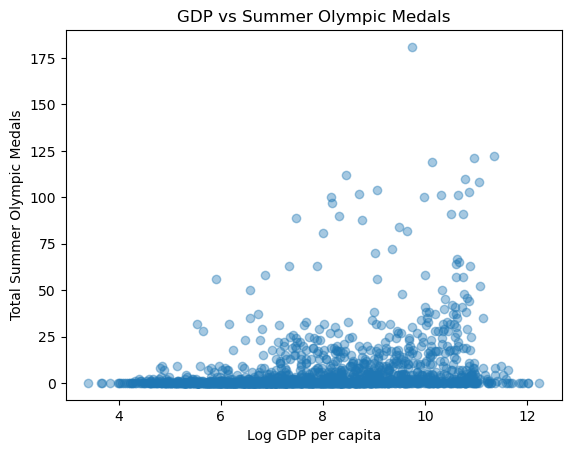

In [110]:
import matplotlib.pyplot as plt

plt.scatter(
    world_summer_gdp["gdp_pc_log"],
    world_summer_gdp["Total"],
    alpha=0.4
)

plt.xlabel("Log GDP per capita")
plt.ylabel("Total Summer Olympic Medals")
plt.title("GDP vs Summer Olympic Medals")
plt.show()

In [111]:
# ==============================
# HOST VALIDATION — existence of host boost (SUMMER)
# ==============================

# 1. Basic comparison: host vs non-host
world_summer_master.groupby("is_host")["Total"].mean()

is_host
0     2.505942
1    67.733333
Name: Total, dtype: float64

In [112]:
# 2. Same-country comparison: host year vs own non-host years

host_years = world_summer_master[world_summer_master["is_host"] == 1]
non_host_years = world_summer_master[world_summer_master["is_host"] == 0]

host_vs_self = (
    host_years
    .merge(
        non_host_years,
        on="NOC",
        suffixes=("_host", "_nonhost")
    )
)

host_vs_self[["Total_host", "Total_nonhost"]].mean()

Total_host       66.589499
Total_nonhost    25.793556
dtype: float64

In [113]:

# 3. Simple uplift ratio
(
    host_vs_self["Total_host"].mean() /
    host_vs_self["Total_nonhost"].mean()
)

2.5816331251445757

In [114]:
# ==============================
# EFFICIENCY METRIC (SUMMER)
# ==============================

world_summer_master["efficiency"] = (
    world_summer_master["Total"] /
    world_summer_master["gdp_pc_log"]
)

In [115]:
efficiency_country_summer = (
    world_summer_master
    .groupby("NOC")
    .agg(
        avg_efficiency=("efficiency", "mean"),
        avg_medals=("Total", "mean"),
        avg_gdp_log=("gdp_pc_log", "mean"),
        olympics=("Year", "count")
    )
    .reset_index()
)

In [116]:
efficiency_country_summer.sort_values(
    "avg_efficiency",
    ascending=False
).head(15)

,NOC,avg_efficiency,avg_medals,avg_gdp_log,olympics
217,USA,10.541855,96.000000,9.892407,30
172,RUS,5.308350,15.333333,8.685507,30
42,CHN,4.926708,20.966667,6.547813,30
75,GBR,3.397950,33.666667,9.469974,30
101,ITA,3.157369,23.866667,9.292690,30
13,AUS,3.019645,20.000000,9.610942,30
105,JPN,3.015751,18.433333,9.451022,30
70,FRA,2.988332,28.933333,9.520533,30
91,HUN,2.597546,17.866667,8.385944,30
213,UKR,2.067644,5.200000,7.609266,30


In [117]:
efficiency_country_summer_filtered = efficiency_country_summer[
    efficiency_country_summer["olympics"] >= 5
]

efficiency_country_summer_filtered.sort_values(
    "avg_efficiency",
    ascending=False
).head(15)

,NOC,avg_efficiency,avg_medals,avg_gdp_log,olympics
217,USA,10.541855,96.000000,9.892407,30
172,RUS,5.308350,15.333333,8.685507,30
42,CHN,4.926708,20.966667,6.547813,30
75,GBR,3.397950,33.666667,9.469974,30
101,ITA,3.157369,23.866667,9.292690,30
13,AUS,3.019645,20.000000,9.610942,30
105,JPN,3.015751,18.433333,9.451022,30
70,FRA,2.988332,28.933333,9.520533,30
91,HUN,2.597546,17.866667,8.385944,30
213,UKR,2.067644,5.200000,7.609266,30


In [118]:
# ====================================
# EXPORT FINAL WORLD SUMMER MASTER
# ====================================

import os

# Ensure processed folder exists
os.makedirs("../data/processed", exist_ok=True)

# Export
world_summer_master.to_csv(
    "../data/processed/world_summer_master_final.csv",
    index=False
)

print("✅ world_summer_master_final.csv exported successfully.")
print("Shape:", world_summer_master.shape)

✅ world_summer_master_final.csv exported successfully.
Shape: (6930, 11)
